# Analyse Exploratoire des Données (EDA) - Masked Face Super Resolution

L'objectif de ce notebook est d'explorer notre jeu de données de visages. Nous allons :
1. Comprendre la répartition des données (images masquées vs originales).
2. Visualiser des paires d'images pour observer les dégradations et les masques.
3. Analyser les dimensions et la distribution des intensités de pixels.

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import cv2 
from PIL import Image

# Variables pour l'affichage
plt.rcParams['figure.figsize'] = (10, 5)

### ÉTAPE 1 : Volumétrie et Structure

In [2]:

data_dir = '../data'
masked_dir = os.path.join(data_dir, 'Masked')
unmasked_dir = os.path.join(data_dir, 'Unmasked')

# Lister et trier les images
masked_images = sorted([os.path.join(masked_dir, f) for f in os.listdir(masked_dir) if f.endswith('.png')])
unmasked_images = sorted([os.path.join(unmasked_dir, f) for f in os.listdir(unmasked_dir) if f.endswith('.png')])

print(f"Nombre d'images masquées : {len(masked_images)}")
print(f"Nombre d'images originales : {len(unmasked_images)}\n")

Nombre d'images masquées : 330
Nombre d'images originales : 330



  ### ÉTAPE 2 : Validation Visuelle

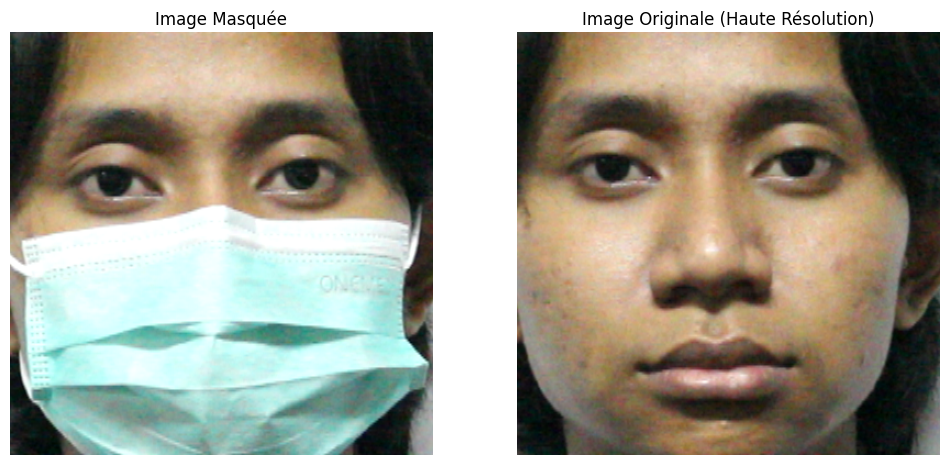

In [3]:
idx = np.random.randint(0, min(len(masked_images), len(unmasked_images)))
img_m_path = masked_images[idx]
img_u_path = unmasked_images[idx]
        
img_m = Image.open(img_m_path)
img_u = Image.open(img_u_path)
        
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_m)
ax[0].set_title('Image Masquée')
ax[0].axis('off')
        
ax[1].imshow(img_u)
ax[1].set_title('Image Originale (Haute Résolution)')
ax[1].axis('off')
plt.show()
        
       

 ### ÉTAPE 3 : Analyse des Dimensions

In [4]:
print("--- Vérification d'une seule image (exemple) ---")
print(f"Masquée - Format: {img_m.format}, Taille: {img_m.size}, Mode: {img_m.mode}")
print(f"Originale - Format: {img_u.format}, Taille: {img_u.size}, Mode: {img_u.mode}\n")

print("--- Vérification des dimensions de tout le dataset ---")
# On utilise un set() pour vérifier s'il n'y a qu'une seule dimension ou plusieurs
all_masked_sizes = set()
all_unmasked_sizes = set()

# Parcourir une sélection rapide (ou toutes les images) pour vérifier les tailles
for m_path, u_path in zip(masked_images, unmasked_images):
    with Image.open(m_path) as im_m:
        all_masked_sizes.add(im_m.size)
    with Image.open(u_path) as im_u:
        all_unmasked_sizes.add(im_u.size)

print(f"Dimensions trouvées dans Masked : {all_masked_sizes}")
print(f"Dimensions trouvées dans Unmasked : {all_unmasked_sizes}")

--- Vérification d'une seule image (exemple) ---
Masquée - Format: PNG, Taille: (385, 385), Mode: RGBA
Originale - Format: PNG, Taille: (385, 385), Mode: RGBA

--- Vérification des dimensions de tout le dataset ---
Dimensions trouvées dans Masked : {(462, 463), (468, 458), (386, 385), (554, 555), (665, 666), (385, 386), (389, 411), (457, 457), (443, 443), (379, 379), (462, 462), (398, 398), (400, 371), (554, 554), (393, 393), (394, 394), (423, 464), (447, 501), (463, 463), (399, 399), (423, 424), (385, 385), (665, 665), (321, 321), (555, 555), (418, 418), (666, 666), (386, 386), (463, 462), (423, 423), (410, 410), (555, 554)}
Dimensions trouvées dans Unmasked : {(480, 572), (665, 666), (385, 386), (462, 463), (666, 666), (386, 386), (463, 463), (665, 665), (385, 385), (462, 462), (321, 321), (386, 385), (554, 555), (463, 462), (555, 555), (554, 554), (555, 554)}


### ÉTAPE 4 : Distribution des valeurs (Histogrammes)

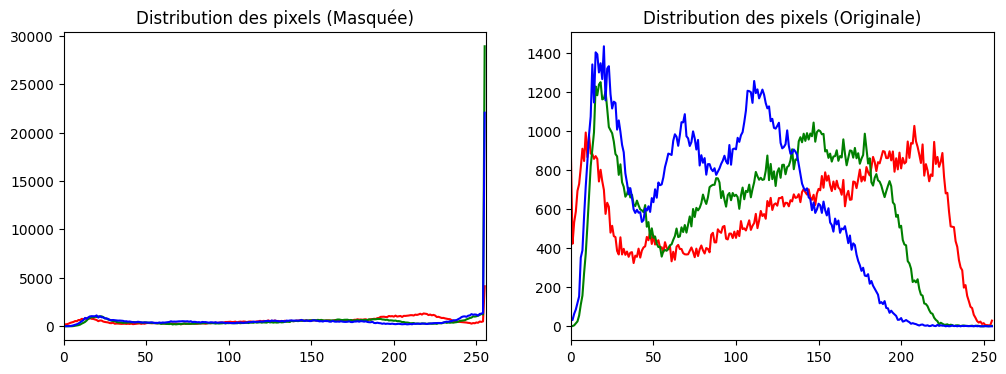

In [5]:
img_m_cv = cv2.cvtColor(cv2.imread(img_m_path), cv2.COLOR_BGR2RGB)
img_u_cv = cv2.cvtColor(cv2.imread(img_u_path), cv2.COLOR_BGR2RGB)
        
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
colors = ('r', 'g', 'b')
        
for i, col in enumerate(colors):
    hist_m = cv2.calcHist([img_m_cv], [i], None, [256], [0, 256])
    ax2[0].plot(hist_m, color=col)
    ax2[0].set_xlim([0, 256])
    ax2[0].set_title("Distribution des pixels (Masquée)")
        
for i, col in enumerate(colors):
    hist_u = cv2.calcHist([img_u_cv], [i], None, [256], [0, 256])
    ax2[1].plot(hist_u, color=col)
    ax2[1].set_xlim([0, 256])
    ax2[1].set_title("Distribution des pixels (Originale)")
plt.show()